# Import Library

In [1]:
!pip install transformers datasets accelerate evaluate scikit-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_class_weight

from datasets import Dataset
import evaluate

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)

import torch
import random

# To Produce Consistent Training Result
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

# Data Importing

In [3]:
# Import Data from CSV

df = pd.read_csv("/content/final_dataset.csv", sep=';')

In [4]:
df.head(10)

,keyword,video_title,text,url,labels
0,Cafe Aesthetic Padang,"The Best Cafés to Work From in Uluwatu, Bali -...",Thanks for sharing the information about co wo...,https://www.youtube.com/watch?v=ZtkzP8t9xr8,2
1,Cafe Aesthetic Padang,"The Best Cafés to Work From in Uluwatu, Bali -...",Super helpful. Wouldn't have thought of coming...,https://www.youtube.com/watch?v=ZtkzP8t9xr8,2
2,Cafe Aesthetic Padang,"The Best Cafés to Work From in Uluwatu, Bali -...",fantastic video! 👌🌴💻,https://www.youtube.com/watch?v=ZtkzP8t9xr8,2
3,Cafe Aesthetic Padang,"The Best Cafés to Work From in Uluwatu, Bali -...",Thanks so much for the good information,https://www.youtube.com/watch?v=ZtkzP8t9xr8,2
4,Cafe Aesthetic Padang,"The Best Cafés to Work From in Uluwatu, Bali -...",All the cafes look amazing definitely will pl...,https://www.youtube.com/watch?v=ZtkzP8t9xr8,2
5,Cafe Aesthetic Padang,"The Best Cafés to Work From in Uluwatu, Bali -...",You have done amazing work. Thank you so much ...,https://www.youtube.com/watch?v=ZtkzP8t9xr8,2
6,Cafe Aesthetic Padang,"The Best Cafés to Work From in Uluwatu, Bali -...",Wow im really enjoy your explanation ..cool cafes,https://www.youtube.com/watch?v=ZtkzP8t9xr8,2
7,Cafe Aesthetic Padang,"The Best Cafés to Work From in Uluwatu, Bali -...","Hey Alex, Thanks for sharing beautiful cafe. I...",https://www.youtube.com/watch?v=ZtkzP8t9xr8,2
8,Cafe Aesthetic Padang,"The Best Cafés to Work From in Uluwatu, Bali -...",Thank you so much for this video! Very helpful 🙏,https://www.youtube.com/watch?v=ZtkzP8t9xr8,2
9,Cafe Aesthetic Padang,"The Best Cafés to Work From in Uluwatu, Bali -...",Uluwatu is my fav place in Bali too,https://www.youtube.com/watch?v=ZtkzP8t9xr8,2


# Data Understanding

In [5]:
# Visualization configuration
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

/tmp/ipykernel_3034/697809609.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='label_text', order=['Negative', 'Neutral', 'Positive'], palette=['#ff4c4c', '#d3d3d3', '#4c9aff'])


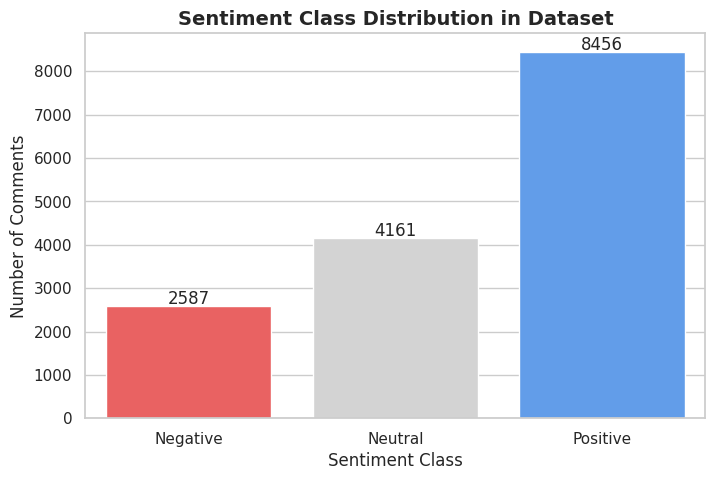

In [6]:
# Map label integers to readable text for the chart
label_mapping = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
df['label_text'] = df['labels'].map(label_mapping)

# Create Bar Chart for Sentiment Distribution
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='label_text', order=['Negative', 'Neutral', 'Positive'], palette=['#ff4c4c', '#d3d3d3', '#4c9aff'])

plt.title('Sentiment Class Distribution in Dataset', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment Class', fontsize=12)
plt.ylabel('Number of Comments', fontsize=12)

# Add value annotations on top of the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.show()

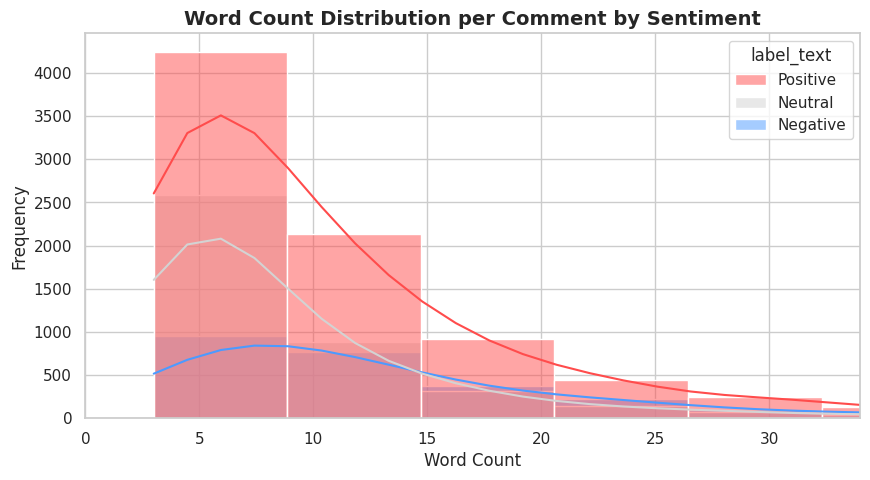


Descriptive Statistics of Word Count:


,count,mean,std,min,25%,50%,75%,max
label_text,,,,,,,,
Negative,2587.0,14.600696,15.255526,3.0,7.0,11.0,17.0,267.0
Neutral,4161.0,10.351118,13.158684,3.0,4.0,7.0,11.0,296.0
Positive,8456.0,12.528855,15.136380,3.0,5.0,8.0,14.0,295.0


In [7]:
# Calculate the word count per comment
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='word_count', hue='label_text', bins=50, kde=True, palette=['#ff4c4c', '#d3d3d3', '#4c9aff'])

plt.title('Word Count Distribution per Comment by Sentiment', fontsize=14, fontweight='bold')
plt.xlabel('Word Count', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xlim(0, df['word_count'].quantile(0.95)) # Clip outliers for a cleaner plot
plt.show()

print("\nDescriptive Statistics of Word Count:")
display(df.groupby('label_text')['word_count'].describe())

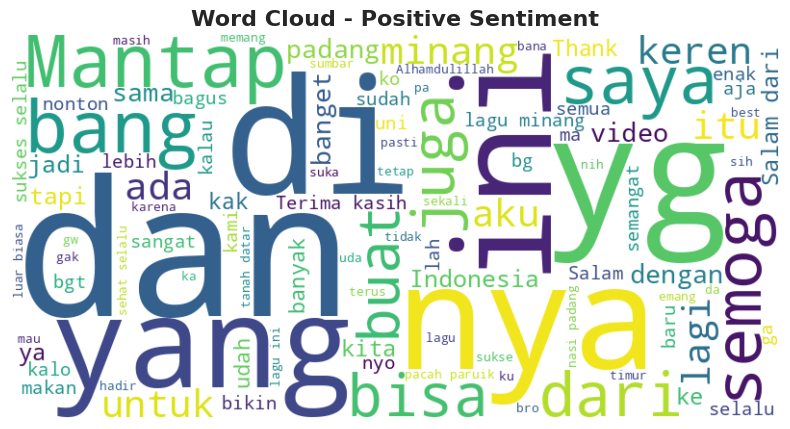

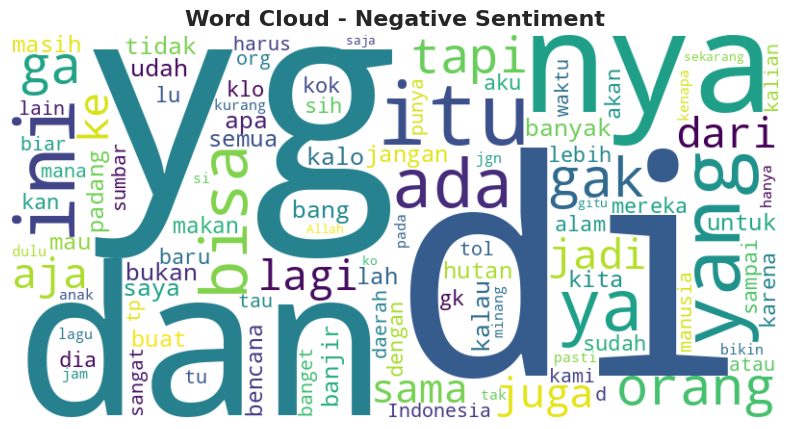

In [8]:
def generate_wordcloud(sentiment_label, title):
    text_data = " ".join(df[df['labels'] == sentiment_label]['text'].astype(str))

    wordcloud = WordCloud(width=800, height=400, background_color='white',
                          max_words=100, colormap='viridis').generate(text_data)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(title, fontsize=16, fontweight='bold')
    plt.axis("off")
    plt.show()

# Execute the function to view Word Clouds for Positive, and Negative sentiments
generate_wordcloud(2, "Word Cloud - Positive Sentiment")
generate_wordcloud(0, "Word Cloud - Negative Sentiment")

# Data Preparation

In [9]:
def clean_text(text):
  if not isinstance(text, str):
    return ""

  text = re.sub(r"http\S+|www\S+|https\S+", "", text, flags=re.MULTILINE) # Remove URL/LINK
  text = re.sub(r"@\w+", "", text) # Remove Mention
  text = text.lower() # Lower Case Text
  text = re.sub(r'[^a-z0-9\s\?\!\.,]', '', text) # Remove other character other than alphabet, numbers and basic punctuation
  text = re.sub(r"\s+", " ", text).strip() # Remove excess space, tab, or newline

  return text

df["clean_text"] = df["text"].apply(clean_text)

In [10]:
df.head(10)

,keyword,video_title,text,url,labels,label_text,word_count,clean_text
0,Cafe Aesthetic Padang,"The Best Cafés to Work From in Uluwatu, Bali -...",Thanks for sharing the information about co wo...,https://www.youtube.com/watch?v=ZtkzP8t9xr8,2,Positive,14,thanks for sharing the information about co wo...
1,Cafe Aesthetic Padang,"The Best Cafés to Work From in Uluwatu, Bali -...",Super helpful. Wouldn't have thought of coming...,https://www.youtube.com/watch?v=ZtkzP8t9xr8,2,Positive,23,super helpful. wouldnt have thought of coming ...
2,Cafe Aesthetic Padang,"The Best Cafés to Work From in Uluwatu, Bali -...",fantastic video! 👌🌴💻,https://www.youtube.com/watch?v=ZtkzP8t9xr8,2,Positive,3,fantastic video!
3,Cafe Aesthetic Padang,"The Best Cafés to Work From in Uluwatu, Bali -...",Thanks so much for the good information,https://www.youtube.com/watch?v=ZtkzP8t9xr8,2,Positive,7,thanks so much for the good information
4,Cafe Aesthetic Padang,"The Best Cafés to Work From in Uluwatu, Bali -...",All the cafes look amazing definitely will pl...,https://www.youtube.com/watch?v=ZtkzP8t9xr8,2,Positive,11,all the cafes look amazing definitely will pla...
5,Cafe Aesthetic Padang,"The Best Cafés to Work From in Uluwatu, Bali -...",You have done amazing work. Thank you so much ...,https://www.youtube.com/watch?v=ZtkzP8t9xr8,2,Positive,16,you have done amazing work. thank you so much ...
6,Cafe Aesthetic Padang,"The Best Cafés to Work From in Uluwatu, Bali -...",Wow im really enjoy your explanation ..cool cafes,https://www.youtube.com/watch?v=ZtkzP8t9xr8,2,Positive,8,wow im really enjoy your explanation ..cool cafes
7,Cafe Aesthetic Padang,"The Best Cafés to Work From in Uluwatu, Bali -...","Hey Alex, Thanks for sharing beautiful cafe. I...",https://www.youtube.com/watch?v=ZtkzP8t9xr8,2,Positive,19,"hey alex, thanks for sharing beautiful cafe. i..."
8,Cafe Aesthetic Padang,"The Best Cafés to Work From in Uluwatu, Bali -...",Thank you so much for this video! Very helpful 🙏,https://www.youtube.com/watch?v=ZtkzP8t9xr8,2,Positive,10,thank you so much for this video! very helpful
9,Cafe Aesthetic Padang,"The Best Cafés to Work From in Uluwatu, Bali -...",Uluwatu is my fav place in Bali too,https://www.youtube.com/watch?v=ZtkzP8t9xr8,2,Positive,8,uluwatu is my fav place in bali too


In [11]:
# Remove Empty Row of Cleaned Text

df = df[df["clean_text"] != ""]

# Remove Duplicates

df = df.drop_duplicates(subset=["clean_text"])

print(f"Total Row for Training: {len(df)}")

Total Row for Training: 15095


In [12]:
# Subset Clean Text and Labels Column
df_model = df[["clean_text", "labels"]].copy()

# Rename Columns
df_model.rename(columns={"clean_text": "text", "labels": "label"}, inplace=True)

# Export Dataset (Backup)
df_model.to_csv("cleaned_comments.csv", sep=';', index=False)

# Model Training

In [13]:
# Data Splitting
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df_model["text"].tolist(),
    df_model["label"].tolist(),
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=df_model["label"].tolist()
)

print(f"Training Data Row: {len(train_texts)}")
print(f"Testing Data Row: {len(test_texts)}")

Training Data Row: 12076
Testing Data Row: 3019


In [14]:
# Class Weight for Unbalanced Dataset
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

weights_tensor = torch.tensor(class_weights_array, dtype=torch.float)
print(f"Class Weight (Negative, Neutral, Positive): {weights_tensor}")

Class Weight (Negative, Neutral, Positive): tensor([1.9474, 1.2161, 0.6009])


In [15]:
# Tokenizer
tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")

# Convert List to HuggingFace Dataset Format
train_dataset = Dataset.from_dict({"text": train_texts, "labels": train_labels})
test_dataset = Dataset.from_dict({"text": test_texts, "labels": test_labels})

def tokenizer_func(text):
  return tokenizer(text["text"], padding="max_length", truncation=True, max_length=128)

# Apply Tokenizer
tokenized_train = train_dataset.map(tokenizer_func, batched=True)
tokenized_test = test_dataset.map(tokenizer_func, batched=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Map:   0%|          | 0/12076 [00:00<?, ? examples/s]

Map:   0%|          | 0/3019 [00:00<?, ? examples/s]

In [16]:
class CustomTrainer(Trainer):
  def __init__(self, *args, class_weights=None, **kwargs):
    super().__init__(*args, **kwargs)
    self.class_weights = class_weights

  def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
    labels = inputs.pop("labels")
    outputs = model(**inputs)
    logits = outputs.logits

    if self.class_weights is not None:
      self.class_weights = self.class_weights.to(logits.device)
      loss_fct = torch.nn.CrossEntropyLoss(weight=self.class_weights)
    else:
      loss_fct = torch.nn.CorssEntropyLoss()

    loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))

    return (loss, outputs) if return_outputs else loss

In [17]:
# Download XLM-R
model = AutoModelForSequenceClassification.from_pretrained("xlm-roberta-base", num_labels=3)

# Evaluate Matrics
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_metric.compute(predictions=predictions, references=labels)["accuracy"]
    f1 = f1_metric.compute(predictions=predictions, references=labels, average="macro")["f1"]
    return {"accuracy": acc, "f1_macro": f1}

# Training Config
training_args = TrainingArguments(
    output_dir="./model_output",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro"
)

trainer = CustomTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    compute_metrics=compute_metrics,
    class_weights=weights_tensor
)

# Start Training
trainer.train()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.912709,0.701731,0.739318,0.696111
2,0.647549,0.659702,0.763167,0.719560
3,0.520231,0.649492,0.765816,0.730389
4,0.430887,0.750267,0.775754,0.735858
5,0.361992,0.819195,0.777741,0.739026


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=3775, training_loss=0.561284185750595, metrics={'train_runtime': 2128.8637, 'train_samples_per_second': 28.363, 'train_steps_per_second': 1.773, 'total_flos': 3971697040604160.0, 'train_loss': 0.561284185750595, 'epoch': 5.0})

# Inference

In [18]:
from transformers import pipeline

analyzer = pipeline(
    task="text-classification",
    model=model,
    tokenizer=tokenizer,
    device=0
)

label_map = {
    "LABEL_0": "Negative",
    "LABEL_1": "Neutral",
    "LABEL_2": "Positive"
}

testing_sentences = [
    "Cafe ini rancak bana, view-nya amazing banget buat nugas santai sore-sore!", # Positive
    "Jan pitih se dipikia! Kerjanya overwork tapi salary underpaid, ndak sasuai ekspektasi do.", # Negative
    "Apo ado loker part-time daerah Padang? I need info secepatnya ya min, makasih.",  # Neutral
    "Tempatnya cozy sih, but palayanannyo lamo bana, literally nunggu 1 jam cuma buat es teh.", # Code-mixed
    "Sumpah ini tempat healing the best di Padang, vibesnya chill abis dan kopinya lamak rasonyo!", # Positive
    "Baa kok gitu sistem kerjanya? Totally a scam, red flag banget mending skip ae lah kawan-kawan.", # Code-mixed Negative
    "Permisi min, nanya dong kalau dari bandara BIM ke lokasi cafe ini brapa jam ya estimasinya?", # Neutral
    "Wow rajin banget pelayannya, saking rajinnya orderan awak baru tibo setelah 2 jam menunggu. Mantap! 🙃", # Sarcasm (Negative)
    "Ndak talok den ngekos disiko lai, the environment is so toxic, ibu kosnyo suko mambana.", # Code-Mixed English + Minangkabau Language
    "Jujur kecewa banget, dibilangnya free wifi tapi pas dicoba ndak amuah konek gai, literally buang-buang waktu se nunggu siko.", # Code-mixed Negative
    "Menu baru di resto ini lamak bana, harganya juga affordable banget buat kantong mahasiswa, rancak lah pokoknya highly recommended!" # Code-Mixed Positive
]

prediction_result = analyzer(testing_sentences)

print("=== TESTING RESULT INFERENCE XLM-R ===")
for text, result in zip(testing_sentences, prediction_result):
    real_label = result['label']
    text_label = label_map.get(real_label, real_label)
    confidence = result['score'] * 100

    print(f'Text     : "{text}"')
    print(f'Prediction : {text_label} (Confidence: {confidence:.2f}%)')
    print("-" * 50)

=== TESTING RESULT INFERENCE XLM-R ===
Text     : "Cafe ini rancak bana, view-nya amazing banget buat nugas santai sore-sore!"
Prediction : Positive (Confidence: 99.66%)
--------------------------------------------------
Text     : "Jan pitih se dipikia! Kerjanya overwork tapi salary underpaid, ndak sasuai ekspektasi do."
Prediction : Negative (Confidence: 99.49%)
--------------------------------------------------
Text     : "Apo ado loker part-time daerah Padang? I need info secepatnya ya min, makasih."
Prediction : Neutral (Confidence: 98.48%)
--------------------------------------------------
Text     : "Tempatnya cozy sih, but palayanannyo lamo bana, literally nunggu 1 jam cuma buat es teh."
Prediction : Neutral (Confidence: 61.70%)
--------------------------------------------------
Text     : "Sumpah ini tempat healing the best di Padang, vibesnya chill abis dan kopinya lamak rasonyo!"
Prediction : Positive (Confidence: 99.65%)
--------------------------------------------------
Te

# Export Model

In [19]:
# Export Model
trainer.save_model("/content/")

# Export Tokenizer
tokenizer.save_pretrained("/content/")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/tokenizer_config.json', '/content/tokenizer.json')